Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20180125'
  Extraction of runtime standard library version was: '20191114'


Welcome to JupyROOT 6.16/00


Warning in <TFile::Append>: Replacing existing TH1: h_jetGirth_quark (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_jetGirth_gluon (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_jetMass_quark (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_jetMass_gluon (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_jetPt_quark (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_jetPt_gluon (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_nGenJetPF_quark (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_nGenJetPF_gluon (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_QG_mult_quark (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_QG_mult_gluon (Potential memory leak).
Info in <TCanvas::Print>: pdf file /home/tiznado/Desktop/histogram_p

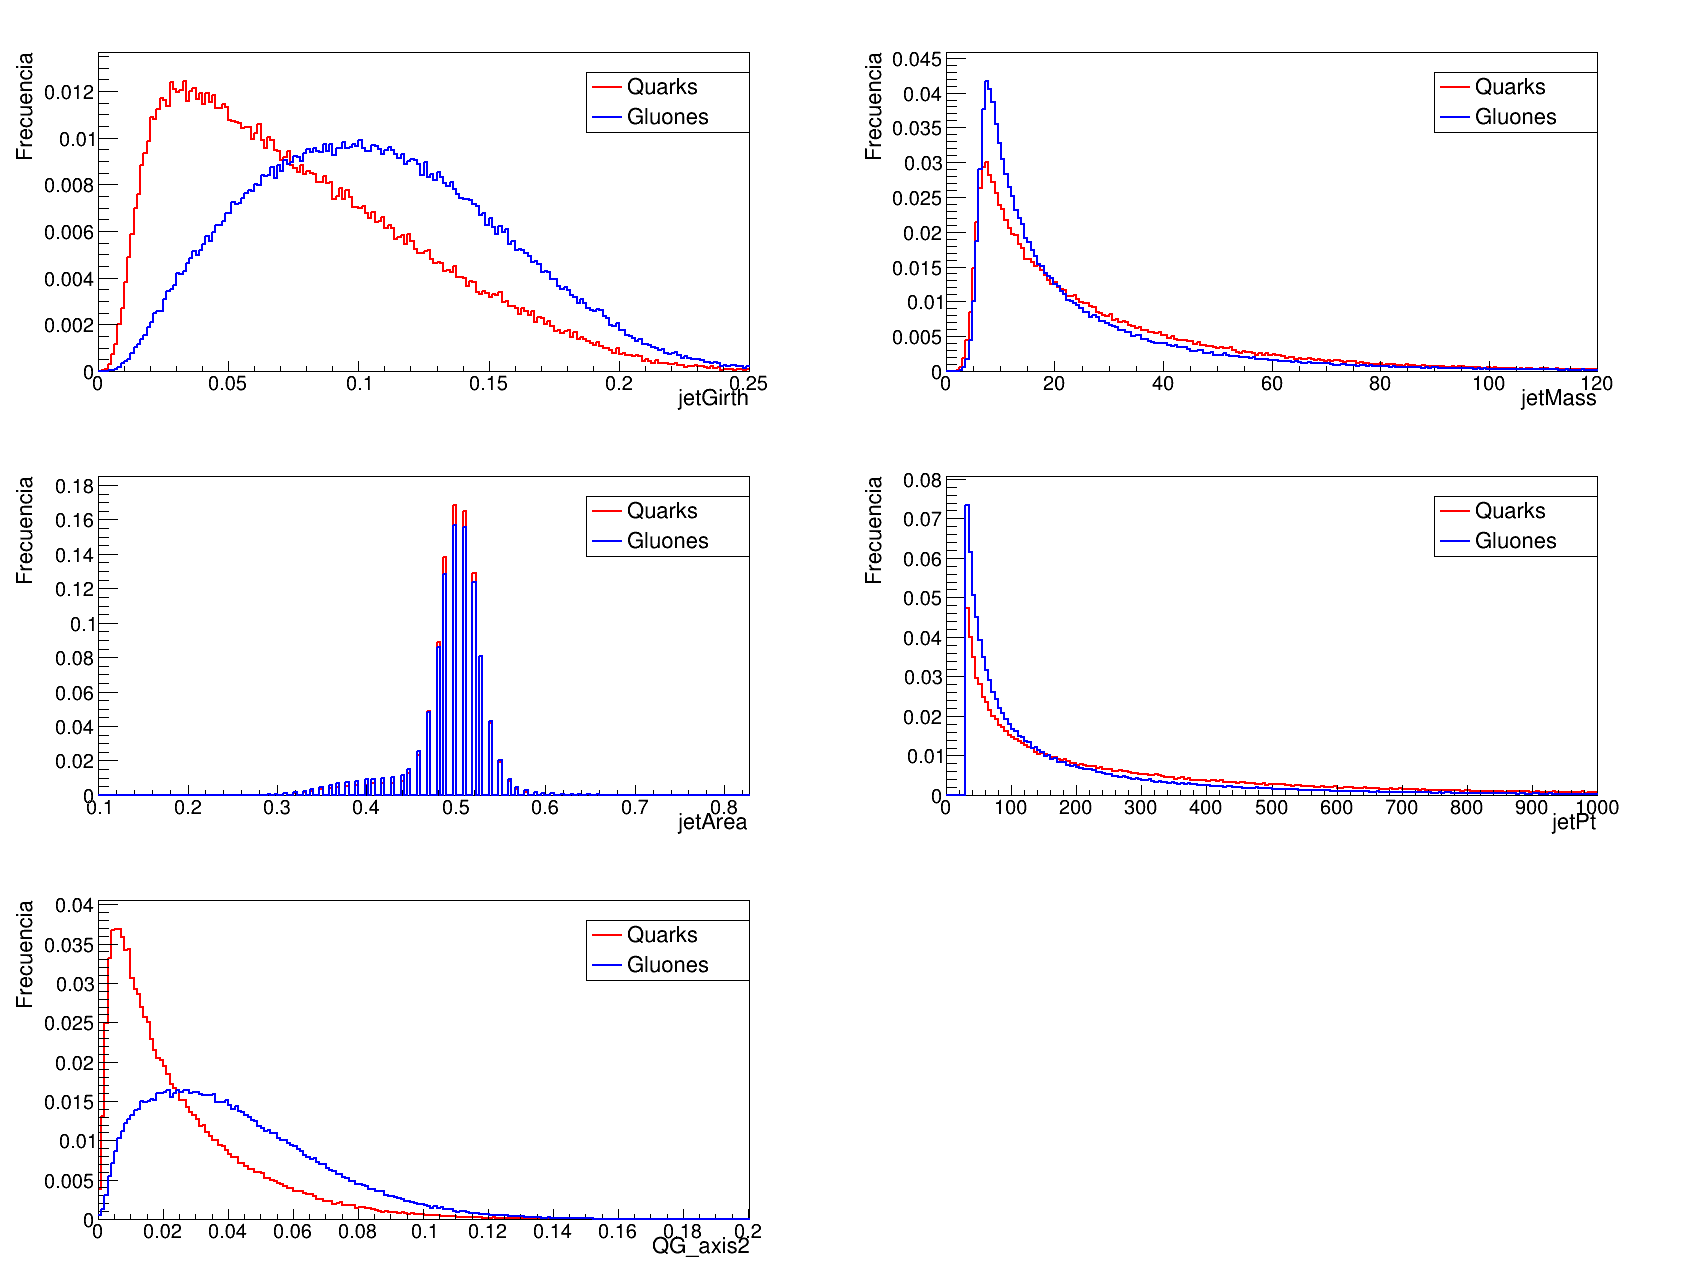

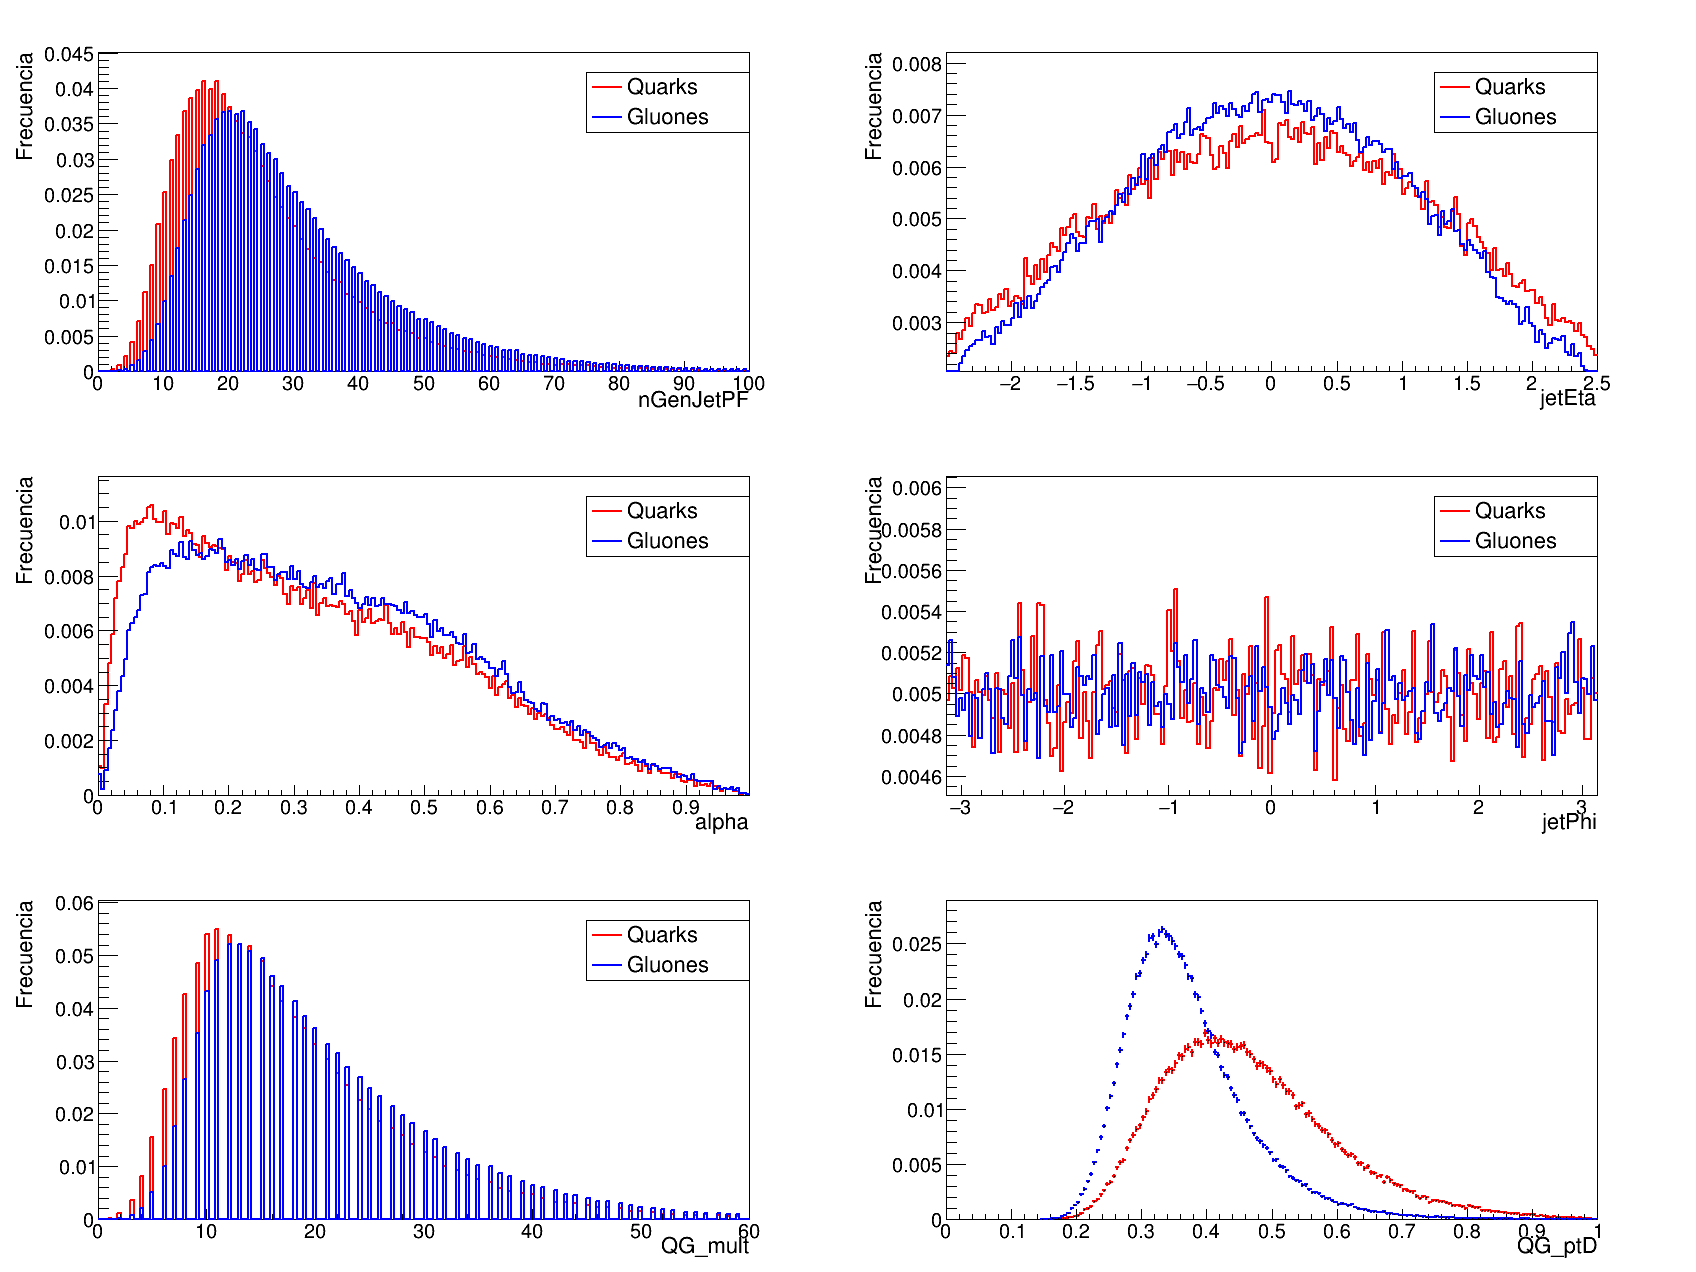

In [1]:
#Programa para graficar variables especificadas en uno o mas archivos .root

import ROOT

#Abrir archivos .root con el camino especificado

filepath1 = "/home/tiznado/Downloads/JetNtuple_RunIISummer16_13TeV_MC_111.root"
filepath2 = "/home/tiznado/Downloads/JetNtuple_RunIISummer16_13TeV_MC_105.root"

f = ROOT.TFile.Open(filepath1)
f1 = ROOT.TFile.Open(filepath2)

#Accedemos ambos arboles de datos
tree = f.Get("AK4jets/jetTree")
tree1 = f1.Get("AK4jets/jetTree")

#Creamos un objeto TChain para poder agregar mas de una muestra
t = ROOT.TChain("AK4jets/jetTree")
t.Add("/home/tiznado/Downloads/JetNtuple_RunIISummer16_13TeV_MC_111.root")
t.Add("/home/tiznado/Downloads/JetNtuple_RunIISummer16_13TeV_MC_105.root")

#Conseguimos los nombres de las columnas de los datos
#column_names = [branch.GetName() for branch in t.GetListOfBranches()]
column_names = ['jetGirth', 'jetMass', 'jetArea', 'jetPt', 'QG_axis2', 'nGenJetPF', 'jetEta', 'alpha', 'jetPhi', 'QG_mult', 'QG_ptD']


#Creamos primer objeto canvas
c1 = ROOT.TCanvas("c1", "Jet Histograms (Part 1)", 1700, 1300)
c1.Divide(2, 3)
c1.SetTopMargin(0)

c1.SetLeftMargin(0)
c1.SetBottomMargin(0)

#Creamos segundo objeto canvas
c2 = ROOT.TCanvas("c2", "Jet Histograms (Part 2)", 1700, 1300)
c2.Divide(2, 3)
c2.SetLeftMargin(0.2)
c2.SetBottomMargin(200)

#Valores minimos y maximos
min_values = {}
max_values = {}
for column_name in column_names:
    min_values[column_name] = t.GetMinimum(column_name)
    max_values[column_name] = t.GetMaximum(column_name)

#Histogramas
histograms = []  
legends = []  
for i, column_name in enumerate(column_names):
    #Primera mitad de los histogramas
    if i < len(column_names) // 2:  
        c1.cd(i + 1)
    #Segunda mitad de los histogramas
    else: 
        c2.cd(i - len(column_names) // 2 + 1)
    
    h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, min_values[column_name], max_values[column_name])
    h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, min_values[column_name], max_values[column_name])
    if column_name == "jetGirth":
        h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, 0, 0.25)
        h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, 0, 0.25)
    if column_name == "jetMass":
        h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, 0, 120)
        h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, 0, 120)
    if column_name == "jetPt":
        h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, 0, 1000)
        h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, 0, 1000)
    if column_name == 'nGenJetPF':
        h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, 0, 100)
        h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, 0, 100)
    if column_name == 'QG_mult':
        h_quark = ROOT.TH1F("h_" + column_name + "_quark", column_name + " Distribution", 200, 0, 60)
        h_gluon = ROOT.TH1F("h_" + column_name + "_gluon", column_name + " Distribution", 200, 0, 60)
    t.Draw(column_name + ">>h_" + column_name + "_quark", "isPartonUDS == 1", "HIST")
    t.Draw(column_name + ">>h_" + column_name + "_gluon", "isPartonG == 1", "HIST SAME")
    h_quark.SetLineColor(ROOT.kRed)
    h_gluon.SetLineColor(ROOT.kBlue)
    h_quark.SetStats(0)
    h_gluon.SetStats(0)
    legend = ROOT.TLegend(0.7, 0.7, 0.9, 0.85) 
    legend.SetTextSize(0.06)  
    legend.AddEntry(h_quark, "Quarks", "l")
    legend.AddEntry(h_gluon, "Gluones", "l")
    legend.Draw()
    histograms.append((h_quark, h_gluon))
    legends.append(legend)

#Normalizacion de los datos
for h_quark, h_gluon in histograms:
    if h_quark.Integral() != 0:
        h_quark.Scale(1.0 / h_quark.Integral())
    if h_gluon.Integral() != 0:
        h_gluon.Scale(1.0 / h_gluon.Integral())

#Caracteristicas de los histogramas
for i, (h_quark, h_gluon) in enumerate(histograms):
    h_quark.SetTitle("")
    h_quark.GetYaxis().SetTitle("Frecuencia")
    h_quark.GetYaxis().SetTitleSize(0.06)
    h_quark.GetYaxis().SetTitleOffset(0.95)
    h_quark.GetYaxis().SetLabelSize(0.055)  
    h_quark.GetXaxis().SetLabelSize(0.055)  
    h_quark.GetXaxis().SetTitle(column_names[i]) 

    h_quark.GetXaxis().SetTitleOffset(0.7)  
    h_quark.GetXaxis().SetTitleSize(0.06)
    h_quark.SetLineWidth(2)
    h_gluon.SetLineWidth(2)
    h_quark.Draw()
    h_gluon.Draw("SAME")
    max_height = max(h_quark.GetMaximum(), h_gluon.GetMaximum())
    h_quark.SetMaximum(1.1 * max_height)  
    h_gluon.SetMaximum(1.1 * max_height)

#Dibujamos los canvas y se guardan como pdf.
c1.Draw()
c2.Draw()
c1.SaveAs("/home/tiznado/Desktop/histogram_part1.pdf")
c2.SaveAs("/home/tiznado/Desktop/histogram_part2.pdf")
